# Remove Recording Beginning

Find the beginning of each DAIC-WOZ interview from its Whisper transcript, then trim the audio and transcript to the detected anchor.

## 1. Inspect Anchor Words

Record the first occurrence of `hi`, `thanks`, and `today` in every Whisper transcript for initial exploration.

In [ ]:
import re
import pandas as pd 
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
ASR_DIR = PROJECT_ROOT / "outputs" / "asr" / "whisper_base"
ANCHOR_OUTPUT = PROJECT_ROOT / "outputs" / "anchor" / "anchor_word_first_times.csv"

TARGET_WORDS = ["hi", "thanks", "today"]


def contains_word(text: str, word: str) -> bool:
    text = str(text).lower()
    return re.search(rf"\b{re.escape(word)}\b", text) is not None


rows = []

for csv_path in sorted(ASR_DIR.glob("*_whisper.csv")):
    data_id = int(csv_path.stem.split("_")[0])
    df = pd.read_csv(csv_path)

    row = {
        "data_id": data_id,
    }

    for word in TARGET_WORDS:
        hit = None

        for _, seg in df.iterrows():
            if contains_word(seg["Text"], word):
                hit = seg
                break

        if hit is None:
            row[f"{word}_time"] = None
            row[f"{word}_text"] = None
        else:
            row[f"{word}_time"] = hit["Start_Time"]
            row[f"{word}_text"] = hit["Text"]

    rows.append(row)

anchor_df = pd.DataFrame(rows)

anchor_df.to_csv(
    ANCHOR_OUTPUT,
    index=False,
)

anchor_df.head()

len(anchor_df)

275

### Check Transcripts Without Anchor Words

Identify transcripts where none of the initial anchor words were found.

In [2]:
missing_all = anchor_df[
    anchor_df["hi_time"].isna()
    & anchor_df["thanks_time"].isna()
    & anchor_df["today_time"].isna()
]

print(
    f"Files with no anchors found: {len(missing_all)}"
)

missing_all.head()

Files with no anchors found: 26


,data_id,hi_time,hi_text,thanks_time,thanks_text,today_time,today_text
12,312,NaN,NaN,NaN,NaN,NaN,NaN
20,320,NaN,NaN,NaN,NaN,NaN,NaN
33,333,NaN,NaN,NaN,NaN,NaN,NaN
51,352,NaN,NaN,NaN,NaN,NaN,NaN
54,355,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Visualize Anchor Timing

Plot the first occurrence time of the candidate anchor words across participant IDs.

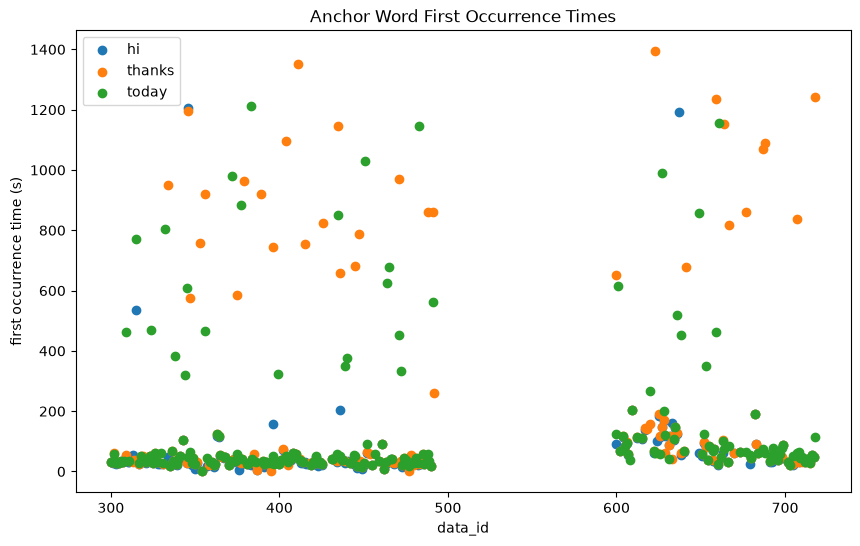

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    anchor_df["data_id"],
    anchor_df["hi_time"],
    label="hi",
)

plt.scatter(
    anchor_df["data_id"],
    anchor_df["thanks_time"],
    label="thanks",
)

plt.scatter(
    anchor_df["data_id"],
    anchor_df["today_time"],
    label="today",
)

plt.xlabel("data_id")
plt.ylabel("first occurrence time (s)")
plt.title("Anchor Word First Occurrence Times")
plt.legend()

plt.show()

### Inspect `hi` Occurrences

Examine the distribution of `hi` separately and count transcripts where it is absent.

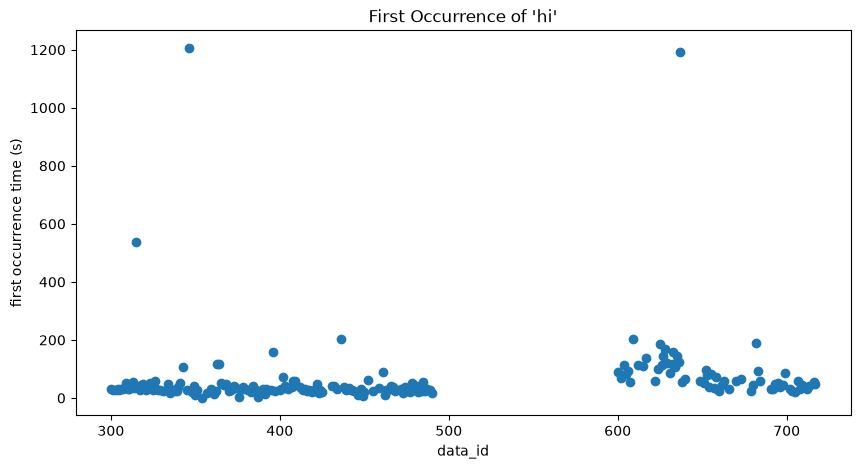

hi not found: 70


In [4]:

plt.figure(figsize=(10, 5))

plt.scatter(
    anchor_df["data_id"],
    anchor_df["hi_time"],
)

plt.xlabel("data_id")
plt.ylabel("first occurrence time (s)")
plt.title("First Occurrence of 'hi'")

plt.show()

hi_missing = anchor_df["hi_time"].isna().sum()

print(f"hi not found: {hi_missing}")

## 3. Find Primary Anchors

Search the first 200 seconds for the primary interview-opening pattern: `Hi, I'm` or `Hi, I am`. Context rows allow an anchor phrase to span multiple Whisper segments.

In [5]:
import re
import pandas as pd
from pathlib import Path

CONTEXT_WINDOW = 3
MAX_TIME = 200

ANCHOR_DIR = PROJECT_ROOT / "outputs" / "anchor"
ANCHOR_DIR.mkdir(parents=True, exist_ok=True)

ANCHOR_PATTERN = r"\bhi\b[\s\W]*\b(i'?m|i\s+am)\b"

hi_im_rows = []

for csv_path in sorted(ASR_DIR.glob("*_whisper.csv")):

    data_id = int(csv_path.stem.split("_")[0])
    df = pd.read_csv(csv_path)

    candidate_rows = df[
        df["Start_Time"] <= MAX_TIME
    ]

    match = None

    for idx in candidate_rows.index:

        start_idx = max(
            0,
            idx - CONTEXT_WINDOW,
        )

        end_idx = min(
            len(df),
            idx + CONTEXT_WINDOW + 1,
        )

        context_df = df.iloc[start_idx:end_idx]

        context_text = " ".join(
            context_df["Text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        if re.search(
            ANCHOR_PATTERN,
            context_text,
            flags=re.IGNORECASE,
        ):
            match = {
                "idx": idx,
                "context_df": context_df,
                "context_text": context_text,
            }
            break

    if match is None:
        continue

    hit_row = df.loc[match["idx"]]
    context_df = match["context_df"]

    hi_im_rows.append(
        {
            "data_id": data_id,
            "time": hit_row["Start_Time"],
            "text": hit_row["Text"],
            "context_start_time": context_df.iloc[0]["Start_Time"],
            "context_end_time": context_df.iloc[-1]["End_Time"],
            "context_text": match["context_text"],
        }
    )

hi_im_df = pd.DataFrame(hi_im_rows)

HI_IM_CANDIDATES = (
    ANCHOR_DIR
    / "hi_im_candidates.csv"
)

hi_im_df.to_csv(
    HI_IM_CANDIDATES,
    index=False,
)

print(f"Found {len(hi_im_df)} hi-im anchors")
hi_im_df.head()
hi_im_ids = set(
    hi_im_df["data_id"]
)

Found 165 hi-im anchors


## 4. Find Secondary Anchors

For transcripts without a primary anchor, search for `Thanks for coming` or `How are you doing today`.

In [6]:
CONTEXT_WINDOW = 3
MAX_TIME = 200

ANCHOR_DIR = PROJECT_ROOT / "outputs" / "anchor"
ANCHOR_DIR.mkdir(parents=True, exist_ok=True)

SECONDARY_ANCHOR_PATTERN = (
    r"\bthanks\b[\s\W]*\bfor\b[\s\W]*\bcoming\b"
    r"|"
    r"\b(are|how\s+are)\b[\s\W]*\byou\b[\s\W]*\bdoing\b[\s\W]*\btoday\b"
)
thanks_for_rows = []

for csv_path in sorted(ASR_DIR.glob("*_whisper.csv")):

    data_id = int(csv_path.stem.split("_")[0])
    if data_id in hi_im_ids:
        continue
    df = pd.read_csv(csv_path)

    candidate_rows = df[
        df["Start_Time"] <= MAX_TIME
    ]

    match = None

    for idx in candidate_rows.index:

        start_idx = max(
            0,
            idx - CONTEXT_WINDOW,
        )

        end_idx = min(
            len(df),
            idx + CONTEXT_WINDOW + 1,
        )

        context_df = df.iloc[start_idx:end_idx]

        context_text = " ".join(
            context_df["Text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        if re.search(
            SECONDARY_ANCHOR_PATTERN,
            context_text,
            flags=re.IGNORECASE,
        ):
            match = {
                "idx": idx,
                "context_df": context_df,
                "context_text": context_text,
            }
            break

    if match is None:
        continue

    hit_row = df.loc[match["idx"]]
    context_df = match["context_df"]

    thanks_for_rows.append(
        {
            "data_id": data_id,
            "time": hit_row["Start_Time"],
            "text": hit_row["Text"],
            "context_start_time": context_df.iloc[0]["Start_Time"],
            "context_end_time": context_df.iloc[-1]["End_Time"],
            "context_text": match["context_text"],
        }
    )

thanks_for_df = pd.DataFrame(thanks_for_rows)

THANKS_FOR_CANDIDATES = (
    ANCHOR_DIR
    / "thanks_for_coming_candidates.csv"
)

thanks_for_df.to_csv(
    THANKS_FOR_CANDIDATES,
    index=False,
)

print(f"Found {len(thanks_for_df)} thanks-for anchors")
thanks_for_df.head()

Found 38 thanks-for anchors


,data_id,time,text,context_start_time,context_end_time,context_text
0,302,50.50,I'll ask a few questions to get a start.,26.00,60.00,"When you're finished, you can go ahead and tak..."
1,326,59.00,Hi.,55.00,64.00,All right. You're good to go. All right. Hi. H...
2,336,62.00,What do I say?,56.00,70.00,"Okay. Okay. Alright. What do I say? Oh, okay. ..."
3,346,36.08,"Oh, that's it.",16.62,47.94,"Whatever. So, firstly, I'm going to shout afte..."
4,347,57.52,Are you okay with this?,24.00,66.52,When she's done she'll let you know she'll say...


## 5. Review Remaining Transcripts

Collect participant IDs that matched neither the primary nor secondary anchor for manual review.

In [7]:
combined_ids = (
    set(hi_im_df["data_id"])
    |
    set(thanks_for_df["data_id"])
)

remaining_df = anchor_df[
    ~anchor_df["data_id"].isin(
        combined_ids
    )
].copy()

print(
    f"Remaining files: {len(remaining_df)}"
)
REMAINING_CANDIDATES = (
    ANCHOR_DIR
    / "remaining_candidates_after_hi_im_and_thanks.csv"
)

remaining_df.to_csv(
    REMAINING_CANDIDATES,
    index=False,
)

print(
    f"Saved to: {REMAINING_CANDIDATES}"
)

Remaining files: 72
Saved to: e:\Project\daic-woz-audio-analysis\outputs\anchor\remaining_candidates_after_hi_im_and_thanks.csv


## 6. Format the Audio Database

Import the reusable formatting pipeline, configure its input and output directories, and trim each audio/transcript pair from the detected anchor.

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT)
)

from src.formatting.format_audio import (
    format_audio_database
)


e:\Project\daic-woz-audio-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configure Paths

Set the Whisper transcript directory, source audio directory, and formatted database destination.

In [9]:
ASR_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "asr"
    / "whisper_base"
)

AUDIO_DIR = (
    PROJECT_ROOT
    / "data"
    / "audio"
)

DATABASE_DIR = (
    PROJECT_ROOT
    / "database"
)

### Run Formatting

Process all transcript/audio pairs and return a log describing formatted, unformatted, or failed records.

In [10]:
log_df = format_audio_database(
    asr_dir=ASR_DIR,
    audio_dir=AUDIO_DIR,
    output_root=DATABASE_DIR,
    max_time=200,
    pre_roll=0.0,
)

Formatting database: 100%|██████████| 275/275 [00:19<00:00, 14.41file/s]
